In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_cleaned1.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_cleaned1.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [3]:
max_visibility = CV_rows["HourlyVisibility"].max()
print("Maximum HourlyVisibility:", max_visibility)

Maximum HourlyVisibility: 643.738


In [4]:
count_over_160 = CV_rows[CV_rows["HourlyVisibility"] > 160].shape[0]
print("Rows with HourlyVisibility > 160:", count_over_160)

Rows with HourlyVisibility > 160: 2141


In [5]:
print(CV_rows[CV_rows["HourlyVisibility"] > 200])

          STATION_ID  LATITUDE  LONGITUDE                 DATE  \
6444939  USW00023206  38.56667    -121.30  2021-05-15 20:00:00   
8347352  USW00093203  39.80000    -121.85  2016-11-17 07:47:00   
8349427  USW00093203  39.80000    -121.85  2017-01-09 07:51:00   

         HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
6444939                  0.0           225.308  2021      5   15    20   
8347352                  0.0           643.738  2016     11   17     7   
8349427                  0.0           337.962  2017      1    9     7   

         minute                   STATION  
6444939       0     SACRAMENTO MATHER AFB  
8347352      47  CHICO ARMY FLYING SCHOOL  
8349427      51  CHICO ARMY FLYING SCHOOL  


In [6]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
#CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

print("CV_rows:", CV_rows.shape)

CV_rows: (10739952, 12)


In [7]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 200.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10373906, 12)


In [8]:
#counting days measured per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        97
1  BAKERSFIELD AP  1929       269
2  BAKERSFIELD AP  1930        97
3  BAKERSFIELD AP  1931       254
4  BAKERSFIELD AP  1932       366


In [9]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


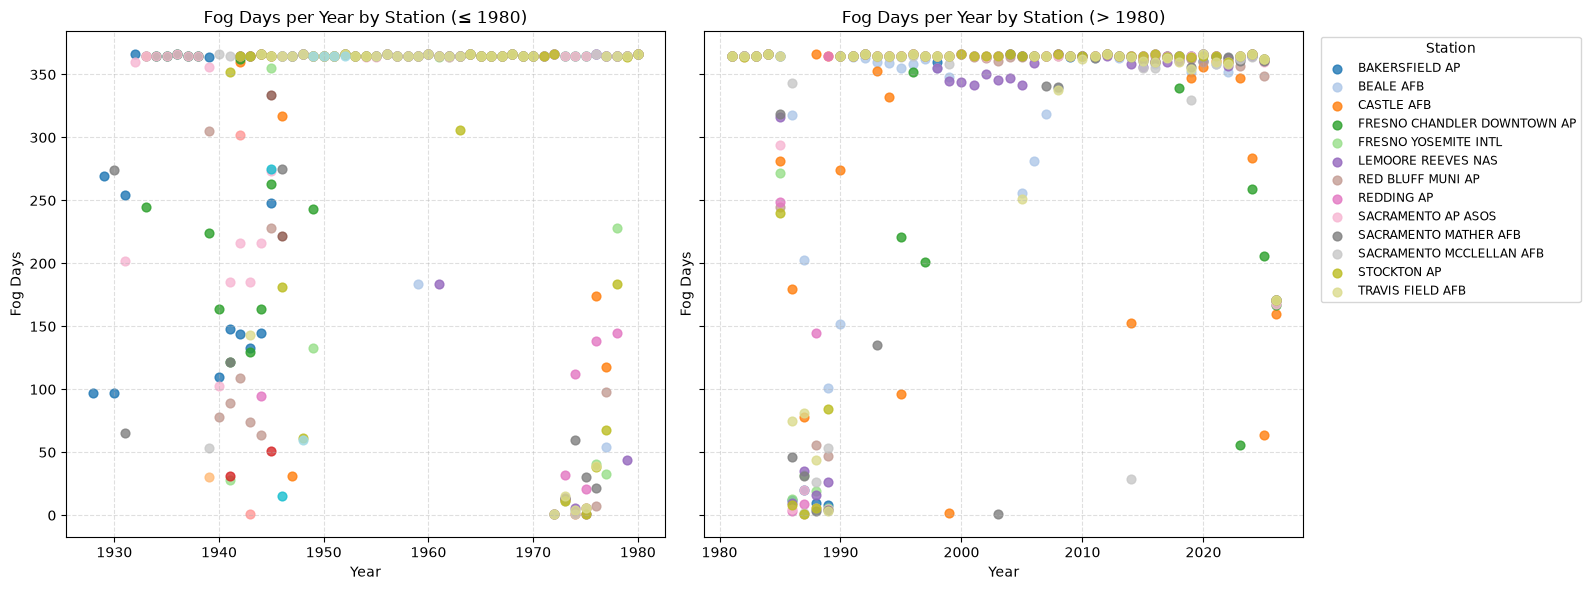

In [10]:
# plot the 'fog' days per year for the outliers for each station
# doing this in order to see where outlier years are
plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

# Make sure to only plot for stations with data back to at least 1970
fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

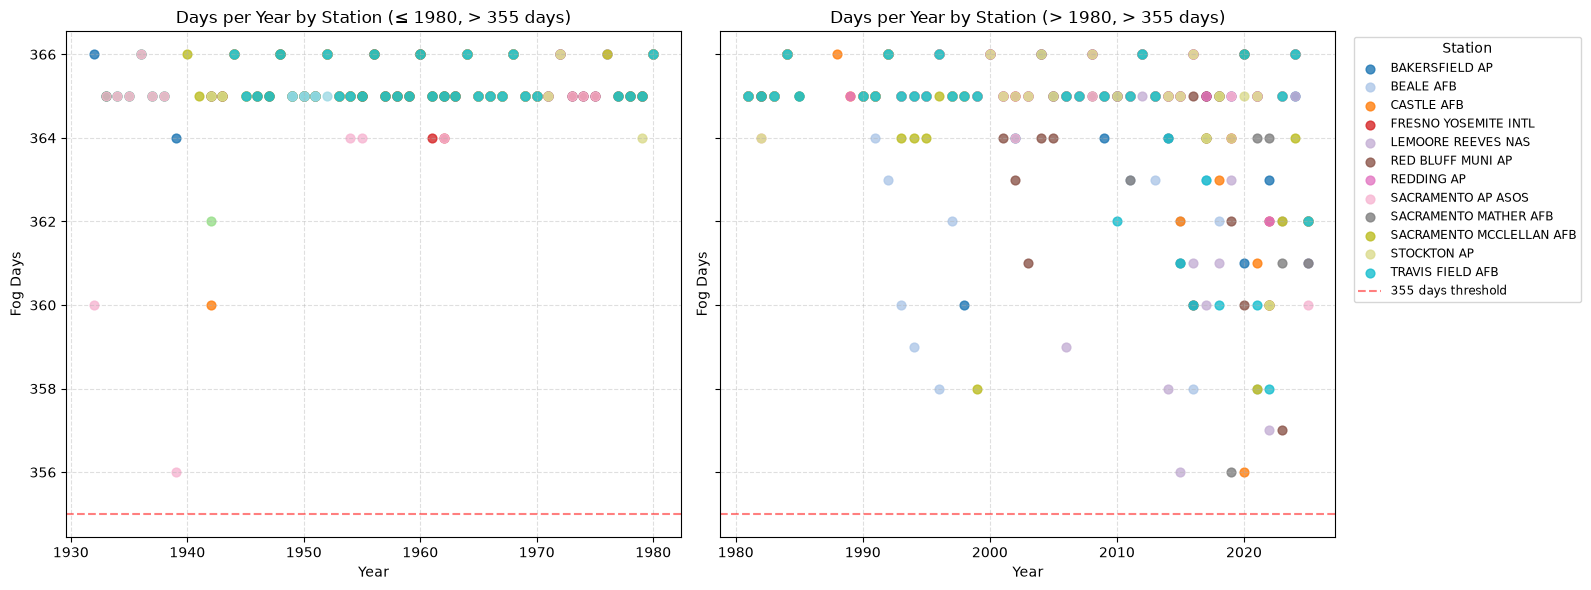

Stations with > 355 days: 16
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'WILLIAMS CAA AIRPORT']


In [11]:
# Remove stations with less than or only 355 days counted
fog_days_year_filtered = fog_days_year[fog_days_year['fog_days'] > 355]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in fog_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1970 stations with > 355 fog days
fog_pre1970_filtered = fog_days_year_filtered[fog_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = fog_pre1970_filtered[fog_pre1970_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Days per Year by Station (≤ 1980, > 355 days)')
axes[1].set_title('Days per Year by Station (> 1980, > 355 days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=355, color='red', linestyle='--', alpha=0.5, label='355 days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 355 days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [12]:
# Remove stations with 200 or fewer days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 355].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 1005
CV_fog_rows_no_outliers: (9353349, 12)


In [13]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]
low_vis_rows_1km = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]

print("CV_fog_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows_1km.shape)


CV_fog_rows_no_outliers with HourlyVisibility < 0.403: (127491, 12)
CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (187643, 12)


In [14]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

low_vis_fog_days_year_1km = (
    low_vis_rows_1km
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)


In [15]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

# -----
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts_1km = low_vis_fog_days_year_1km.groupby("STATION")["year"].nunique()
stations_with_30_years_1km = station_year_counts_1km[station_year_counts_1km >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered_1km = low_vis_fog_days_year_1km[
    low_vis_fog_days_year_1km["STATION"].isin(stations_with_30_years_1km)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years_1km))
print("Filtered low_vis_fog_days_year_1km rows:", low_vis_fog_days_year_filtered_1km.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (810, 3)
Stations kept: 14
Filtered low_vis_fog_days_year_1km rows: (810, 3)


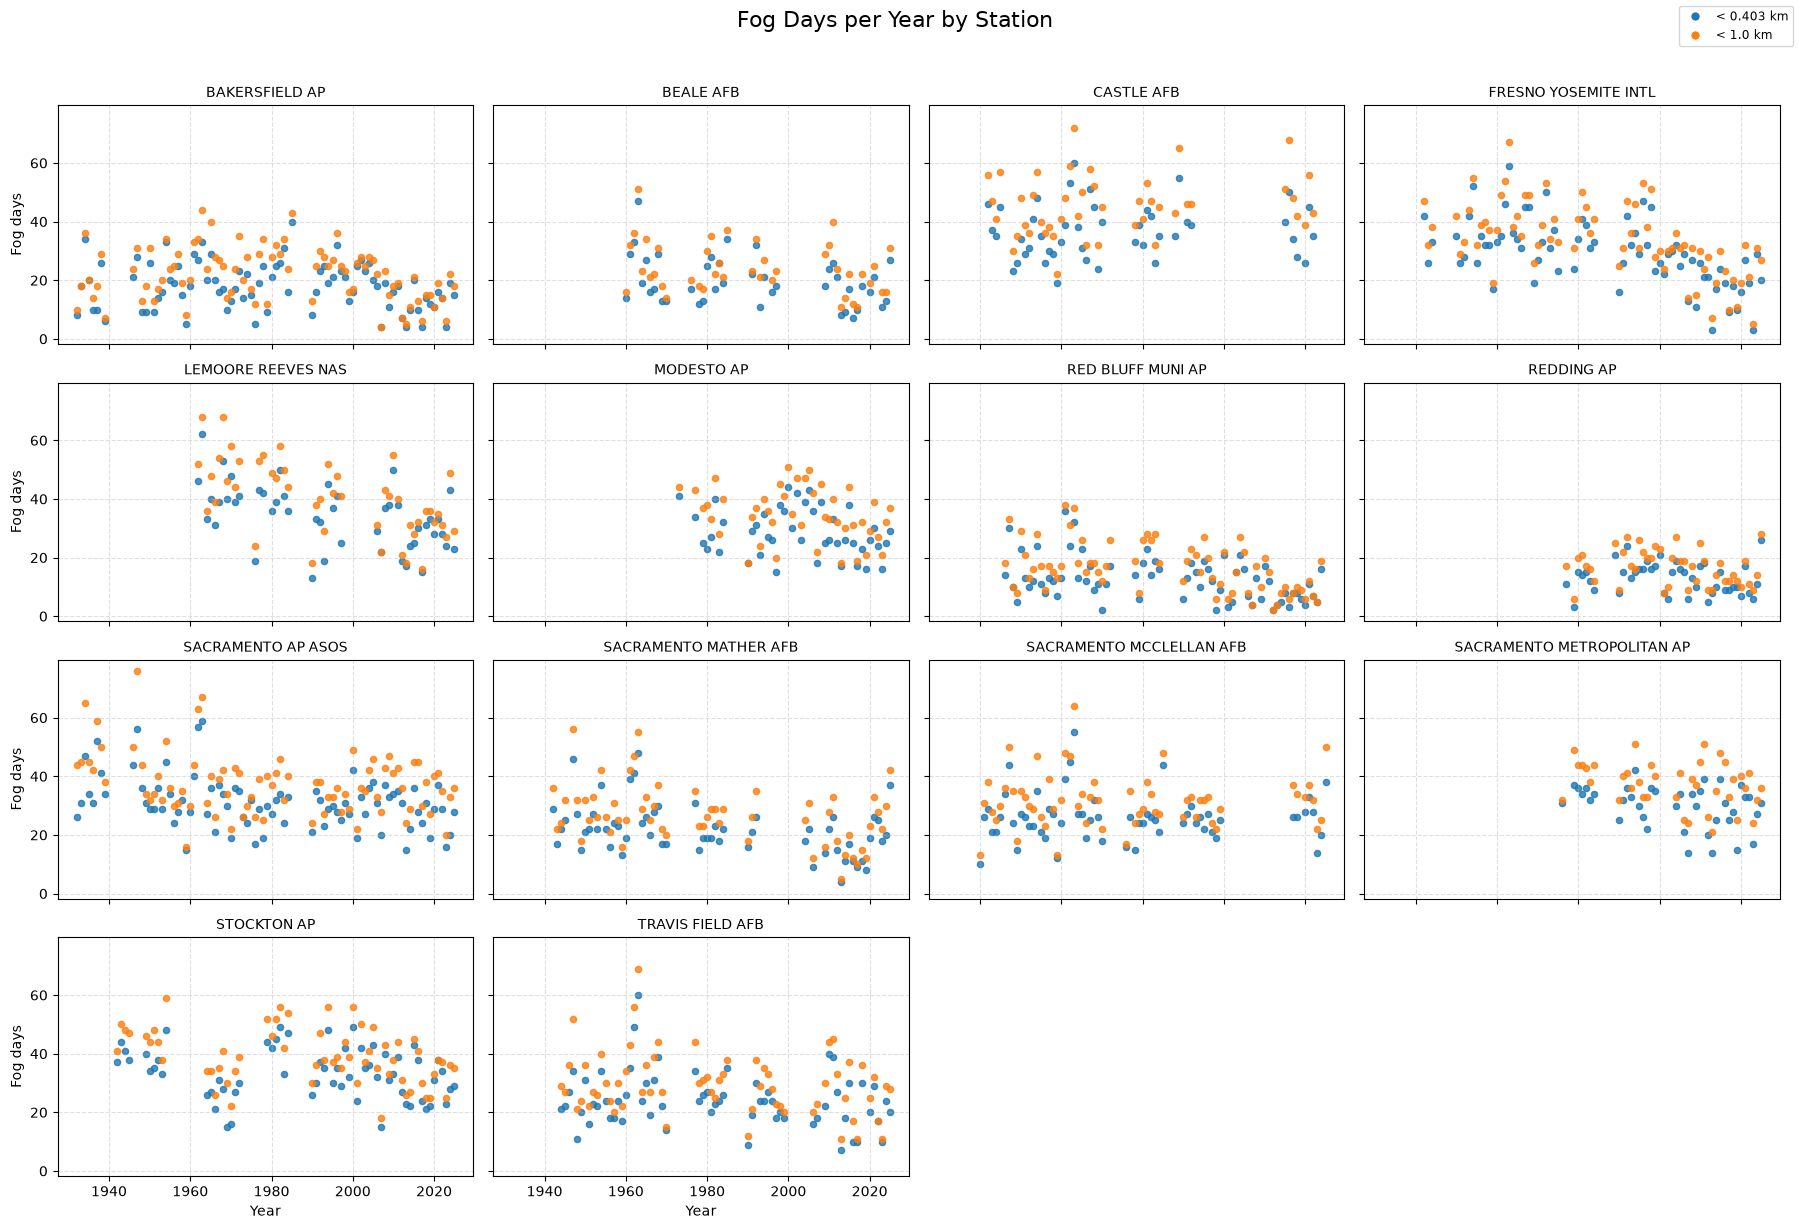

In [51]:
stations = sorted(
    set(low_vis_fog_days_year_filtered["STATION"])
    | set(low_vis_fog_days_year_filtered_1km["STATION"])
)

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    df_h = low_vis_fog_days_year_filtered[
        low_vis_fog_days_year_filtered["STATION"] == station
    ].sort_values("year")
    df_1km = low_vis_fog_days_year_filtered_1km[
        low_vis_fog_days_year_filtered_1km["STATION"] == station
    ].sort_values("year")

    if not df_h.empty:
        ax.scatter(
            df_h["year"],
            df_h["fog_days"],
            s=20,
            alpha=0.8,
            color="tab:blue",
            label="< 0.403 km"
        )
    if not df_1km.empty:
        ax.scatter(
            df_1km["year"],
            df_1km["fog_days"],
            s=20,
            alpha=0.8,
            color="tab:orange",
            label="< 1.0 km"
        )

    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=7),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:orange", markersize=7),
]
fig.legend(handles, ["< 0.403 km", "< 1.0 km"], loc="upper right", fontsize="small")

fig.suptitle("Fog Days per Year by Station", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

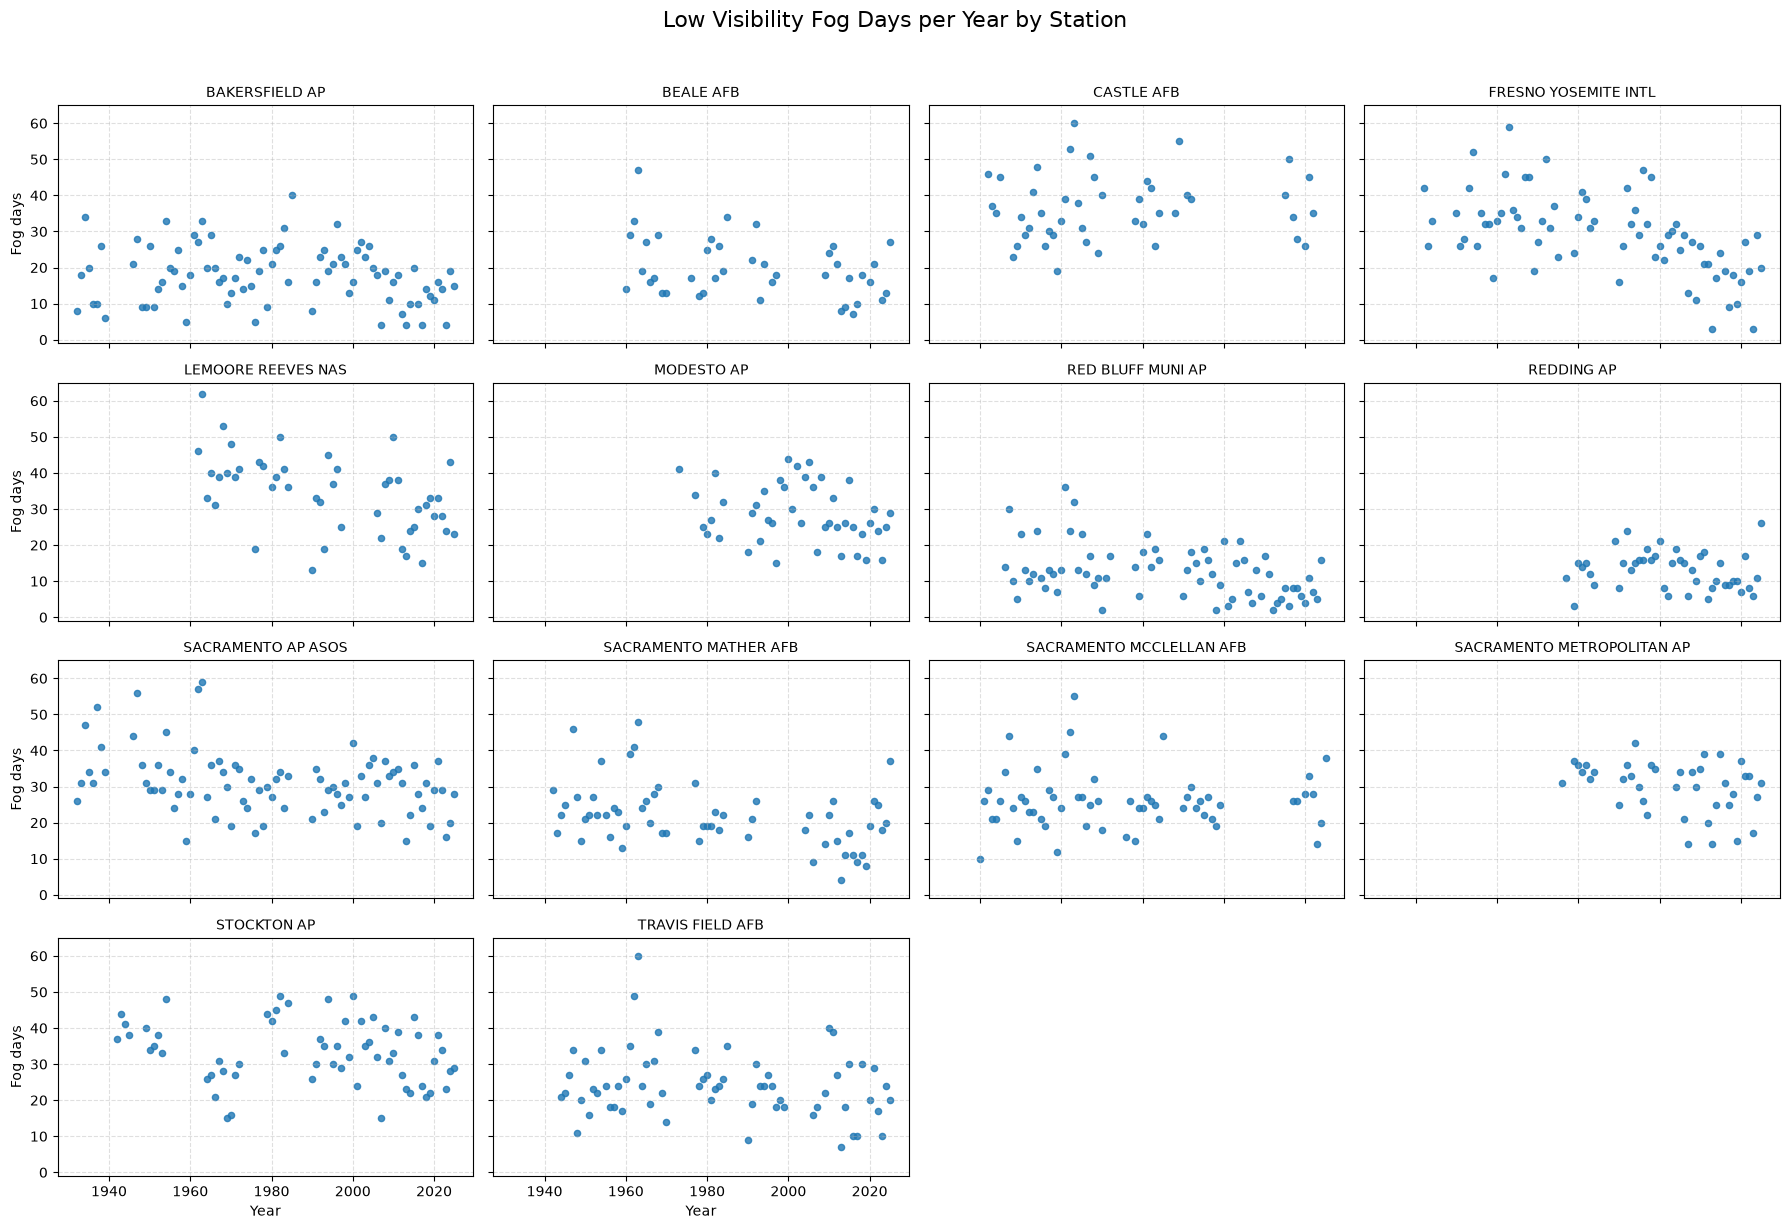

In [17]:
# plot the fog days per year for the filtered stations
stations = low_vis_fog_days_year_filtered['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

# set up the plot:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

# plotting for individual stations:
for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

trend_stats_low_vis_post1980 = []

for station, station_df in post1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980 = (
    post1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.523683  0.098011   
0               BAKERSFIELD AP     42      1980      2025 -0.358438  0.078464   
6            RED BLUFF MUNI AP     40      1980      2024 -0.252024  0.065826   
12                 STOCKTON AP     41      1980      2025 -0.311466  0.092651   
1                    BEALE AFB     27      1980      2025 -0.220241  0.082843   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.170054  0.085316   
4           LEMOORE REEVES NAS     33      1980      2025 -0.213745  0.113695   
7                   REDDING AP     42      1980      2025 -0.096023  0.059692   
5                   MODESTO AP     41      1980      2025 -0.119545  0.097630   
8           SACRAMENTO AP ASOS     41      1980      2025 -0.080874  0.077774   
13            TRAVIS FIELD AFB     34      1980

In [19]:
# Filter for low visibility fog days after 1980
post1980_low_vis_1km = low_vis_fog_days_year_filtered_1km[low_vis_fog_days_year_filtered_1km["year"] >= 1980].copy()

trend_stats_low_vis_post1980_1km = []

for station, station_df in post1980_low_vis_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980_1km.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980_1km = pd.DataFrame(trend_stats_low_vis_post1980_1km).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980_1km[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980_1km = trend_stats_low_vis_post1980_1km[trend_stats_low_vis_post1980_1km["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980_1km)}")
print(significant_low_vis_post1980_1km[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980_1km = (
    post1980_low_vis_1km
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980_1km = smf.ols("fog_days ~ year", data=annual_low_vis_post1980_1km).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980_1km.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
0               BAKERSFIELD AP     42      1980      2025 -0.461675  0.078275   
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.621237  0.105596   
6            RED BLUFF MUNI AP     40      1980      2024 -0.399624  0.075793   
12                 STOCKTON AP     41      1980      2025 -0.395599  0.096472   
4           LEMOORE REEVES NAS     33      1980      2025 -0.366794  0.121874   
1                    BEALE AFB     27      1980      2025 -0.205900  0.093709   
7                   REDDING AP     42      1980      2025 -0.136367  0.068051   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.177202  0.089240   
5                   MODESTO AP     41      1980      2025 -0.152616  0.110207   
13            TRAVIS FIELD AFB     34      1980      2025 -0.111674  0.109061   
9        SACRAMENTO MATHER AFB     28      1980

In [20]:
# make a list of stations with significant trends for fog days after 1980
stations_significant_low_vis_post1980 = significant_low_vis_post1980.loc[
    significant_low_vis_post1980["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_post1980)

Significant post-1980 low-visibility fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'BEALE AFB']


In [21]:
# make a list of stations with significant trends for fog days after 1980
stations_significant_low_vis_post1980_1km = significant_low_vis_post1980_1km.loc[
    significant_low_vis_post1980_1km["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility (<1km) fog-day trend stations:")
print(stations_significant_low_vis_post1980_1km)

Significant post-1980 low-visibility (<1km) fog-day trend stations:
['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'LEMOORE REEVES NAS', 'BEALE AFB']


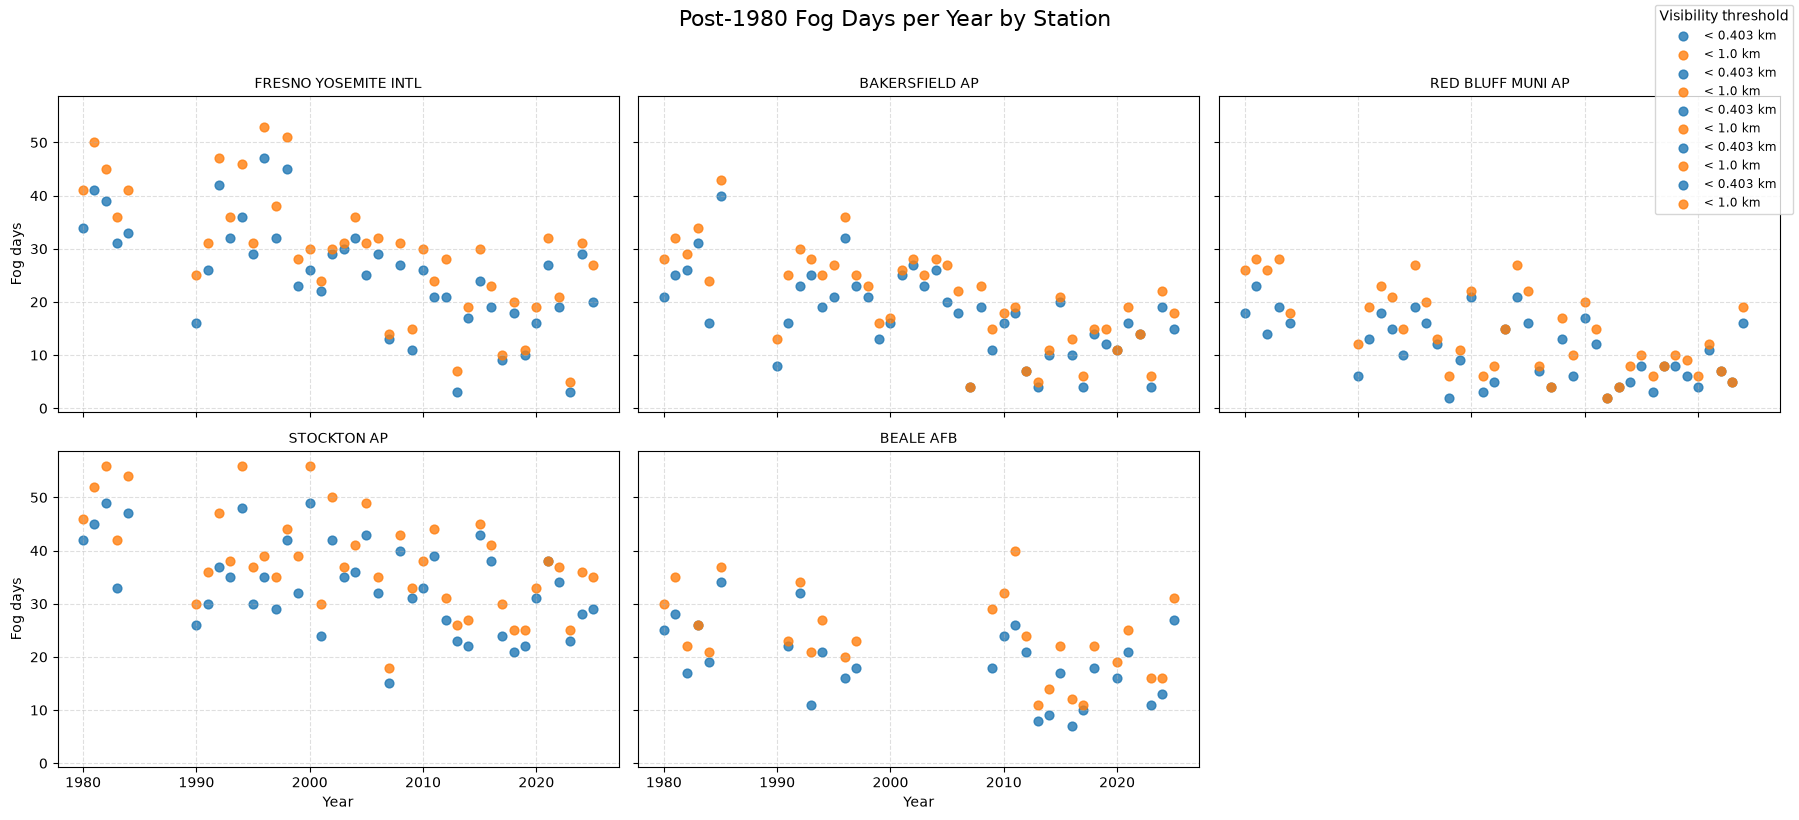

In [52]:
stations = stations_significant_low_vis_post1980

post1980_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["year"] >= 1980
]
post1980_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["year"] >= 1980
]

n_stations = len(stations)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    df_h = post1980_h[post1980_h["STATION"] == station].sort_values("year")
    df_1km = post1980_1km[post1980_1km["STATION"] == station].sort_values("year")

    if not df_h.empty:
        ax.scatter(
            df_h["year"],
            df_h["fog_days"],
            s=40,
            color="tab:blue",
            alpha=0.8,
            label="< 0.403 km"
        )
    if not df_1km.empty:
        ax.scatter(
            df_1km["year"],
            df_1km["fog_days"],
            s=40,
            color="tab:orange",
            alpha=0.8,
            label="< 1.0 km"
        )

    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.legend(loc="upper right", title="Visibility threshold", fontsize="small")
fig.suptitle("Post-1980 Fog Days per Year by Station", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

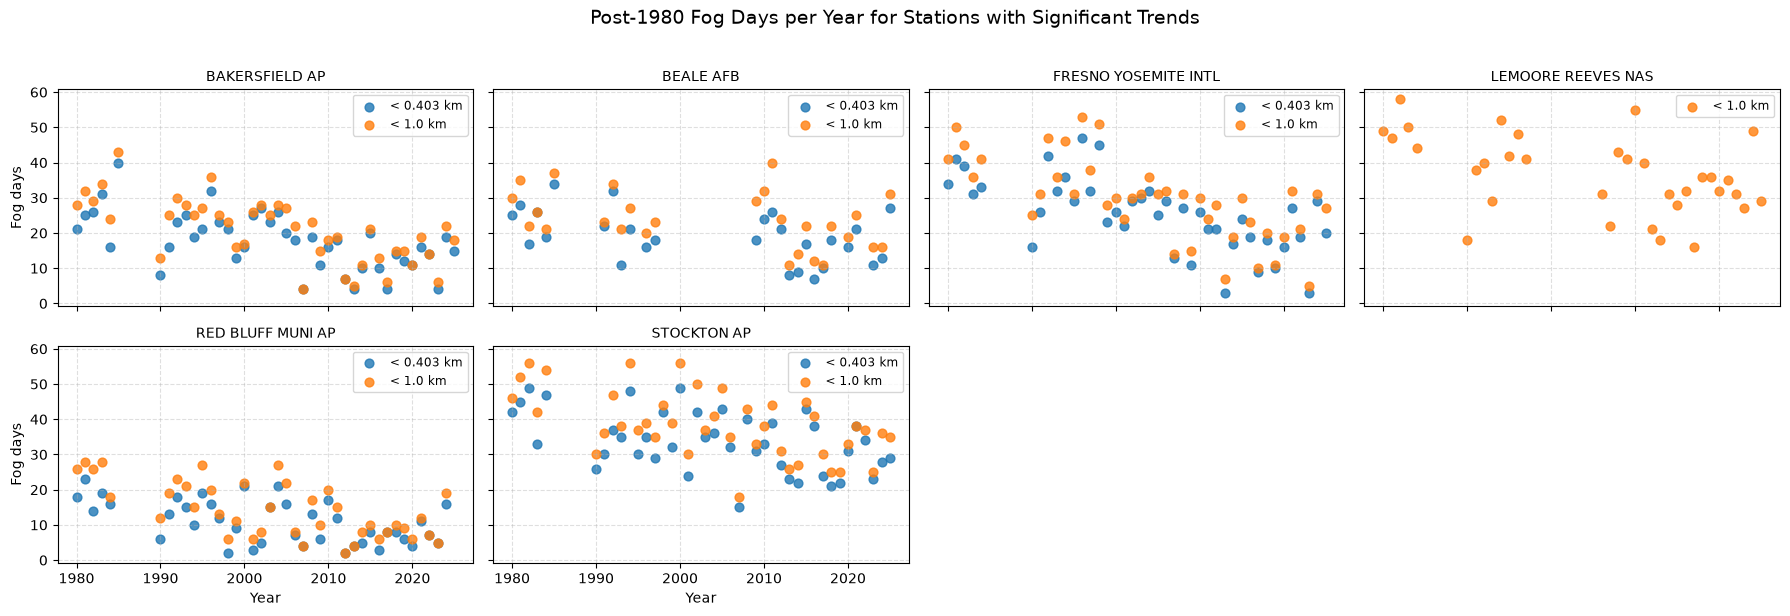

In [53]:
# Plot post-1980 scatterplots per station showing <0.403 km and <1.0 km points.
# If only one threshold has a confirmed trend for a station, plot only that threshold.
stations_h_sig = set(stations_significant_low_vis_post1980)      # <0.403 km significant
stations_1km_sig = set(stations_significant_low_vis_post1980_1km)  # <1.0 km significant

stations_to_plot = sorted(stations_h_sig | stations_1km_sig)
n_stations = len(stations_to_plot)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations_to_plot):
    ax = axes[idx]
    sig_h = station in stations_h_sig
    sig_1km = station in stations_1km_sig

    df_h = post1980_h[post1980_h["STATION"] == station].sort_values("year")
    df_1km = post1980_1km[post1980_1km["STATION"] == station].sort_values("year")

    # Decide which series to plot based on significance
    if sig_h and not df_h.empty:
        ax.scatter(df_h["year"], df_h["fog_days"], s=40, color="tab:blue", alpha=0.8, label="< 0.403 km")
    if sig_1km and not df_1km.empty:
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=40, color="tab:orange", alpha=0.8, label="< 1.0 km")

    # if neither threshold was significant (shouldn't happen due to selection), plot both if available
    if not (sig_h or sig_1km):
        if not df_h.empty:
            ax.scatter(df_h["year"], df_h["fog_days"], s=30, color="tab:blue", alpha=0.6, label="< 0.403 km")
        if not df_1km.empty:
            ax.scatter(df_1km["year"], df_1km["fog_days"], s=30, color="tab:orange", alpha=0.6, label="< 1.0 km")

    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")
    ax.legend(fontsize="small")

# remove unused axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Post-1980 Fog Days per Year for Stations with Significant Trends", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

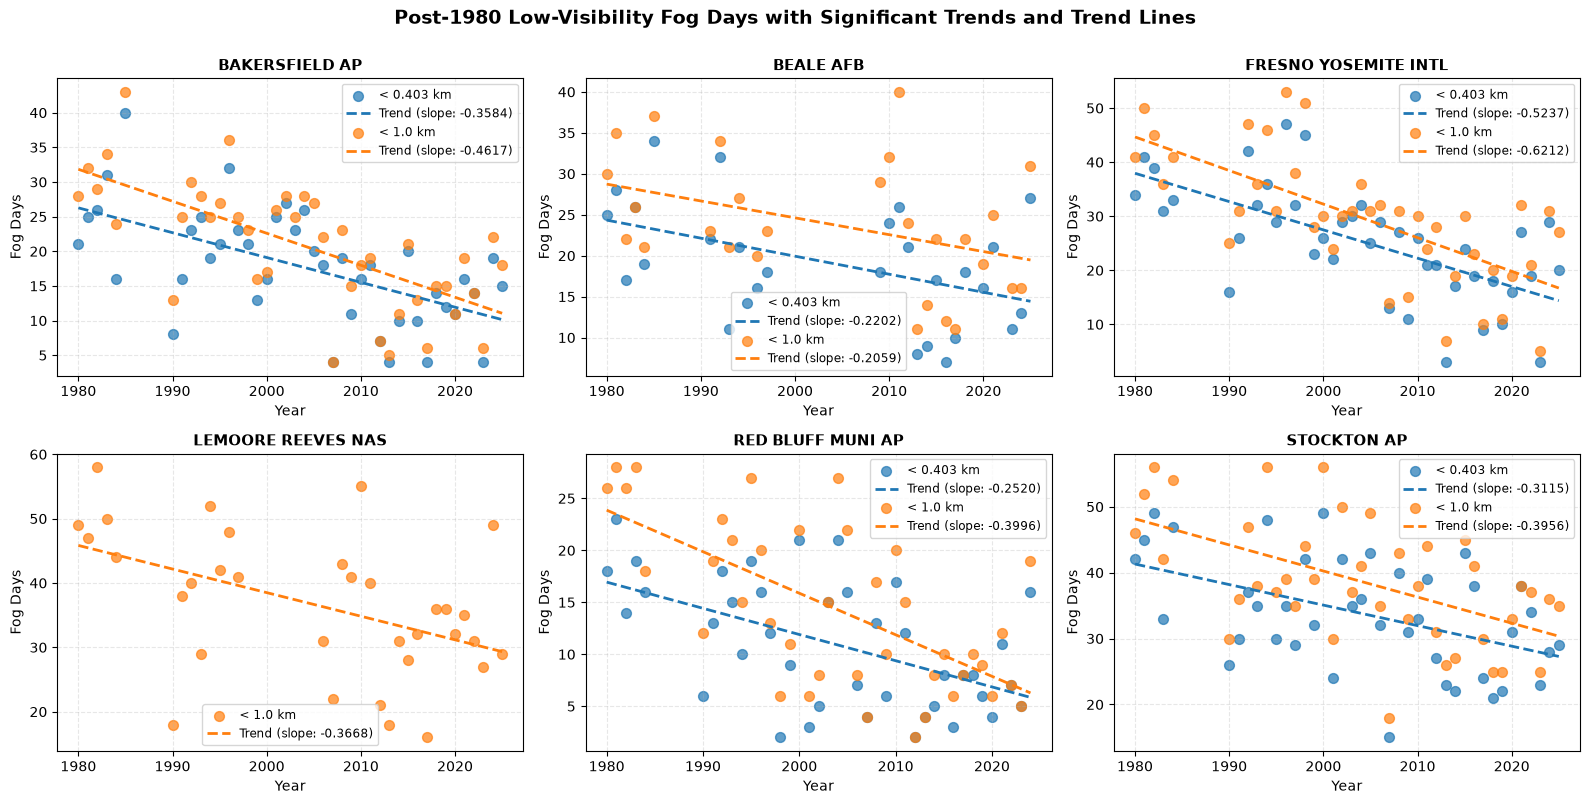

In [56]:
# Create scatterplots with trend lines for stations with significant trends
stations_to_plot = sorted(stations_h_sig | stations_1km_sig)
n_stations = len(stations_to_plot)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, station in enumerate(stations_to_plot):
    ax = axes[idx]
    sig_h = station in stations_h_sig
    sig_1km = station in stations_1km_sig
    
    df_h = post1980_h[post1980_h["STATION"] == station].sort_values("year")
    df_1km = post1980_1km[post1980_1km["STATION"] == station].sort_values("year")
    
    # Plot data and trend lines for significant thresholds
    if sig_h and not df_h.empty:
        ax.scatter(df_h["year"], df_h["fog_days"], s=50, color="tab:blue", alpha=0.7, label="< 0.403 km")
        model_h = smf.ols("fog_days ~ year", data=df_h).fit()
        slope_h = model_h.params["year"]
        trend_line_h = model_h.predict(df_h)
        ax.plot(df_h["year"], trend_line_h, color="tab:blue", linewidth=2, linestyle="--", 
                label=f"Trend (slope: {slope_h:.4f})")
    
    if sig_1km and not df_1km.empty:
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=50, color="tab:orange", alpha=0.7, label="< 1.0 km")
        model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
        slope_1km = model_1km.params["year"]
        trend_line_1km = model_1km.predict(df_1km)
        ax.plot(df_1km["year"], trend_line_1km, color="tab:orange", linewidth=2, linestyle="--",
                label=f"Trend (slope: {slope_1km:.4f})")
    
    ax.set_title(station, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Days")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize="small", loc="best")

# Remove unused axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Post-1980 Low-Visibility Fog Days with Significant Trends and Trend Lines", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

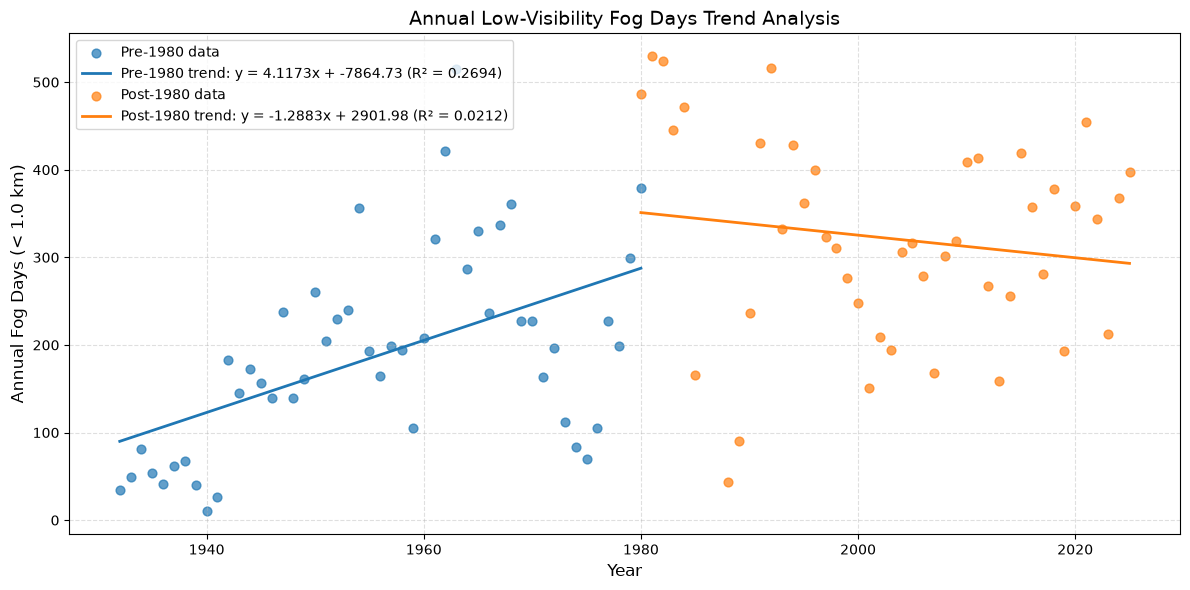

Pre-1980 Trend Equation: y = 4.1173x + -7864.73
Pre-1980 R²: 0.2694

Post-1980 Trend Equation: y = -1.2883x + 2901.98
Post-1980 R²: 0.0212


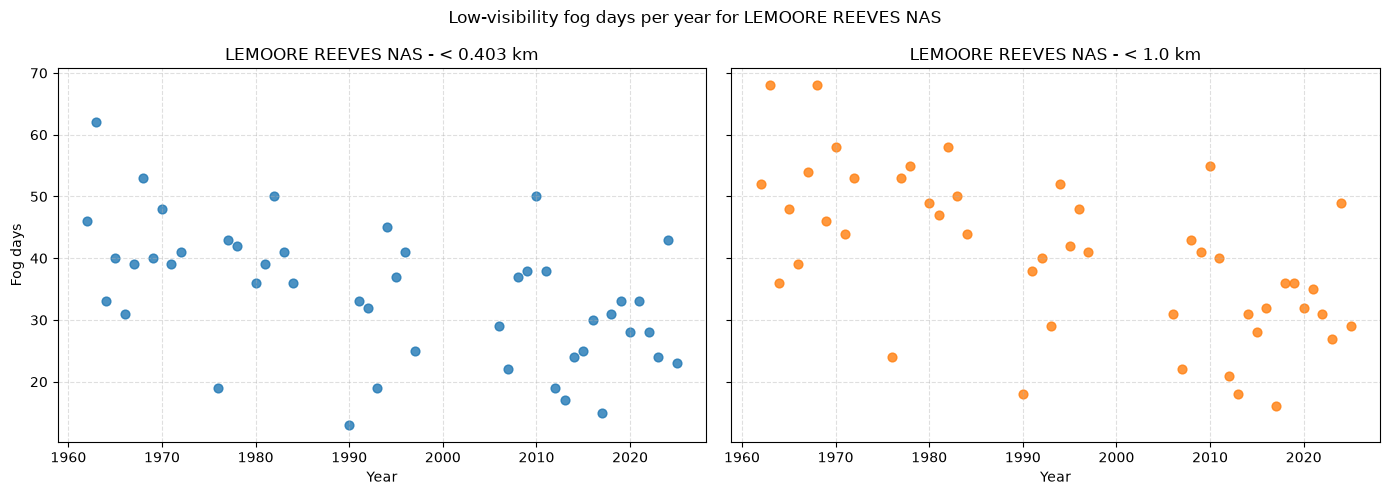

In [43]:
station = "LEMOORE REEVES NAS"

df_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["STATION"] == station
].sort_values("year")

df_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["STATION"] == station
].sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(df_h["year"], df_h["fog_days"], s=40, color="tab:blue", alpha=0.8)
axes[0].set_title(f"{station} - < 0.403 km")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Fog days")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].scatter(df_1km["year"], df_1km["fog_days"], s=40, color="tab:orange", alpha=0.8)
axes[1].set_title(f"{station} - < 1.0 km")
axes[1].set_xlabel("Year")
axes[1].grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Low-visibility fog days per year for LEMOORE REEVES NAS")
plt.tight_layout()
plt.show()